![banner](../../../docs/figs/brand_identity/banner.png)

# Week 8: Image Generation Lab

Build on [Week 4 Multimodal LLMs](../week4/week4_t_multimodal_llm.ipynb) by comparing images made from a short cottage prompt, a more detailed prompt, and three style descriptions. The actual images are generated by the hosted model and saved to the notebook output directory.

**By the end, you can:** describe which visible details changed between prompts; keep the model and seed recorded while comparing wording; and explain that a repeated seed helps reproducibility only within compatible model settings.

**Before you begin:** Hugging Face Inference credentials, internet access, and model access are required. Each model call sends its prompt to an external service. Save generated images and record their settings before discussing them.


<p align="center"><img src="../figs/image_generation_learning_map.svg" alt="Baseline prompt, added detail, and changed style shown as schematic image examples" width="100%"><br><em>Figure 1. Compare generated images after changing one prompt feature at a time; the cottages are schematic.</em></p>

**Use the map:** Start with a baseline, record the model and settings, then compare subject, background, and style. The seed can help control sampling in the practical cells; the main question is what changed in the generated image when the prompt changed.


## Task: compare prompt detail and style

Start with the short cottage prompt, add subject and setting details, then request cartoon, watercolor, and fantasy treatments. Use the images you actually obtain as evidence. The seed is recorded as one generation setting; it does not need a separate concept diagram.


In [2]:
from ccai9012 import sd_utils

In [1]:
from ccai9012.paths import WEEKLY_SCRIPTS_DIR, ensure_output_dir
OUTPUT_DIR = ensure_output_dir(WEEKLY_SCRIPTS_DIR / 'wip' / 'week8')
print(f"Save generated images in {OUTPUT_DIR}")

Save generated images in /Users/kanxuanhe/Document/250421_AI_course/ccai9012/weekly_scripts/wip/week8/output


## Step 0: Initialize Hugging Face Inference Client and Test

Check that the image-generation service is available. Each later generation sends a prompt to an external model.

Enter your HUGGINGFACE_API_KEY:  ········


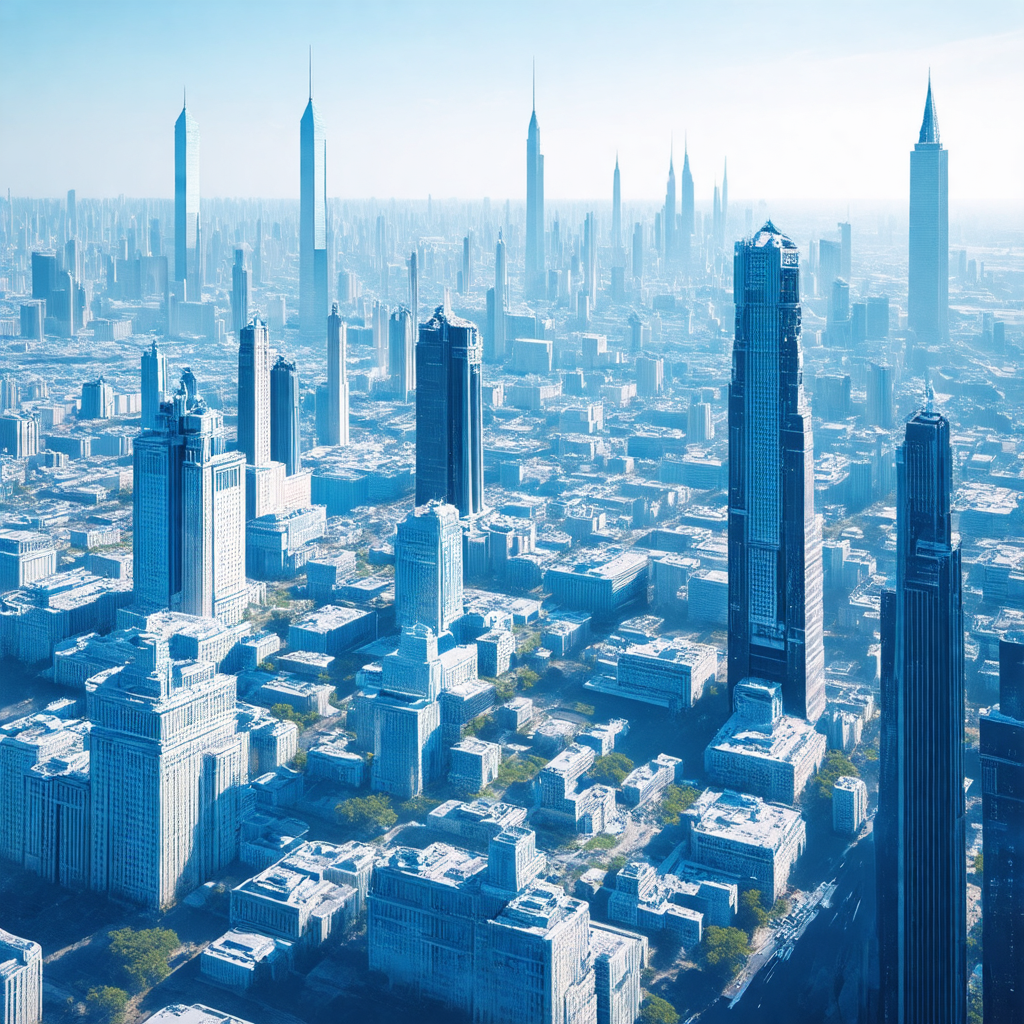

In [5]:
client = sd_utils.SDClient(mode="inference", model_id="stabilityai/stable-diffusion-3-medium-diffusers")
BASE_SEED = 42
images = client.generate_images("a futuristic cityscape", num_images=1, seed=BASE_SEED)

In [ ]:
images[0].save(OUTPUT_DIR / "futuristic_cityscape.png")

## Step 1: Simple Prompt – Explore Randomness

Start with a short prompt as a baseline. Record the prompt and seed, then compare the subject and background in the generated image.

In [ ]:
print("🔹 Step 1: Using a simple prompt to see how randomness affects generation.")
simple_prompt = "A cozy cottage in the forest"
img_1 = client.generate_images(simple_prompt, num_images=1, seed=BASE_SEED)

## Step 2: Add More Descriptive Details

Add one detail to the prompt and check whether it appears in the image. Change only a little at a time so you can see what caused the difference.

In [ ]:
print("\n🔹 Step 2: Adding details to make the model output more controlled.")
detailed_prompt = "A cozy wooden cottage with a red roof in a snowy pine forest, soft morning light, photorealistic, ultra-realistic details, DSLR photo quality, cinematic lighting, 8k resolution, sharp focus, realistic textures, natural atmosphere"
img_2 = client.generate_images(detailed_prompt, num_images=1, seed=BASE_SEED)

## Step 3: Change Style via Prompt Engineering

Try different style words one at a time. Compare the style and check whether the subject still matches the prompt.

In [ ]:
print("\n🔹 Step 3A: Prompt for a cartoon style.")
cartoon_prompt = "A cozy wooden cottage with a red roof in a snowy pine forest, soft morning light, cartoon style, simplified shapes, bold outlines, bright and cheerful colors, flat shading, whimsical atmosphere, 2D animation style"
img_3a = client.generate_images(cartoon_prompt, num_images=1, seed=BASE_SEED)

In [ ]:
print("\n🔹 Step 3B: Prompt for a Watercolor style.")
watercolor_prompt = "A cozy wooden cottage with a red roof in a snowy pine forest, soft morning light, watercolor painting, soft edges, subtle gradients, hand-painted style, delicate textures, light and airy feeling"
img_3b = client.generate_images(watercolor_prompt, num_images=1, seed=BASE_SEED)

In [ ]:
print("\n🔹 Step 3C: Prompt for a Fantasy Illusion style.")
fantasy_prompt = "A cozy wooden cottage with a red roof in a snowy pine forest, soft morning light, fantasy art style, glowing snow, magical atmosphere, storybook illustration, dreamy color palette, high detail"
img_3c = client.generate_images(fantasy_prompt, num_images=1, seed=BASE_SEED)

## Step 4: Compare the output with same prompt

Generate several images from the same prompt and compare their similarities and differences. The same seed can help repeat the random starting point.

**Read the results:** The final cell holds the prompt fixed and varies only the seed. Describe one feature that persists and one that changes. If the hosted model ignores a seed, label that run uncontrolled and report the service behaviour rather than claiming reproducibility.


In [ ]:
print("\n🔹 Step 4: Compare the output with same prompt.")
prompt = "A cozy wooden cottage with a red roof in a snowy pine forest, soft morning light, photorealistic, ultra-realistic details, DSLR photo quality, cinematic lighting, 8k resolution, sharp focus, realistic textures, natural atmosphere"
SEEDS_TO_COMPARE = [BASE_SEED, BASE_SEED + 1, BASE_SEED + 2]
img_4 = [client.generate_images(prompt, num_images=1, seed=seed)[0] for seed in SEEDS_TO_COMPARE]
print("Prompt held fixed; seeds:", SEEDS_TO_COMPARE)

## What to take away

Keep settings fixed and change one prompt element at a time to see what affects the result. **Try next:** Record settings and repeat the experiment. **Limit:** Generation is random and may not follow the prompt exactly.